# 🚀 Churn Prediction: FAANG-Level Data Science Project

**Objective:** Prepare data for churn prediction through comprehensive data analysis, validation, and feature engineering.

**Approach:** This notebook follows industry best practices used at top tech companies (FAANG), including:
- Rigorous data validation (Milestone 2)
- Comprehensive exploratory data analysis
- Feature engineering with domain expertise
- Data preprocessing and transformation
- Feature selection techniques

---

## 📋 Table of Contents

1. **Project Setup & Imports** - Environment configuration
2. **Data Loading & Initial Inspection** - Understanding our data
3. **Data Validation** - Ensuring data quality (Milestone 2)
4. **Exploratory Data Analysis (EDA)** - Discovering patterns
5. **Feature Engineering** - Creating predictive features
6. **Data Preprocessing & Transformation** - Preparing data for modeling
   - 6.1 Class Imbalance Analysis (Sampling needed?)
   - 6.2 Scaling Technique Comparison
   - 6.3 PCA Analysis (Dimensionality reduction)
7. **Feature Selection** - Identifying the most important features

---

**Let's begin!** 🎯

## 1️⃣ Project Setup & Imports

**Why this matters:** 
- Setting up your environment correctly is the foundation of any data science project
- Using consistent libraries ensures reproducibility
- Version control and documentation start here

**What we're doing:**
- Importing all necessary libraries
- Setting display options for better readability
- Configuring random seeds for reproducibility

In [ ]:
# ============================================================
# IMPORTS: Data Manipulation & Analysis
# ============================================================
import pandas as pd  # For working with tabular data (like Excel, but much more powerful)
import numpy as np   # For numerical operations and mathematical functions

# ============================================================
# IMPORTS: Visualization
# ============================================================
import matplotlib.pyplot as plt  # For creating plots and charts
import seaborn as sns            # For beautiful statistical visualizations

# Configure visualization style
sns.set_style("whitegrid")  # Clean grid background
plt.rcParams['figure.figsize'] = (12, 6)  # Default figure size (width, height in inches)
plt.rcParams['font.size'] = 10  # Default font size

# ============================================================
# IMPORTS: Data Preprocessing & Feature Selection
# ============================================================
from sklearn.model_selection import train_test_split  # To split data into train/test sets
from sklearn.preprocessing import StandardScaler      # To normalize numerical features
from sklearn.preprocessing import OneHotEncoder       # To encode categorical variables
from sklearn.compose import ColumnTransformer         # To apply different transforms to different columns
from sklearn.pipeline import Pipeline                 # To chain preprocessing steps together
from sklearn.impute import SimpleImputer             # To handle missing values
from sklearn.feature_selection import SelectKBest, f_classif  # For feature selection
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression   # For feature selection (not modeling)
from sklearn.decomposition import PCA                 # For dimensionality reduction
from sklearn.preprocessing import MinMaxScaler, RobustScaler  # Alternative scaling methods

# ============================================================
# IMPORTS: Handling Class Imbalance (Optional)
# ============================================================
# Note: imbalanced-learn is optional - install with: pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE  # For oversampling minority class
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("[INFO] imbalanced-learn not installed. Install with: pip install imbalanced-learn")

# ============================================================
# IMPORTS: Statistical Analysis
# ============================================================
from scipy import stats  # For statistical tests

# ============================================================
# CONFIGURATION: Reproducibility
# ============================================================
RANDOM_STATE = 42  # This ensures we get the same random results every time
np.random.seed(RANDOM_STATE)

# ============================================================
# CONFIGURATION: Display Options
# ============================================================
pd.set_option('display.max_columns', None)  # Show all columns when printing DataFrame
pd.set_option('display.max_rows', 100)      # Show up to 100 rows
pd.set_option('display.float_format', '{:.2f}'.format)  # Format floats to 2 decimal places

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"🎲 Random seed set to: {RANDOM_STATE}")

# ============================================================
# EXPLANATION:
# ============================================================
# 1. pandas: Think of it as Excel on steroids. It lets us work with tables of data easily.
# 2. numpy: Handles mathematical operations efficiently (arrays, matrices, etc.)
# 3. matplotlib/seaborn: Create beautiful visualizations to understand our data
# 4. sklearn: The go-to library for machine learning in Python
# 5. scipy: Advanced statistical functions
# 
# Setting random_state ensures reproducibility - same code = same results!

✅ All libraries imported successfully!
📦 Pandas version: 2.2.3
📦 NumPy version: 2.1.0
🎲 Random seed set to: 42


## 2️⃣ Data Loading & Initial Inspection

**Why this matters:**
- Understanding your data is the first step in any data science project
- You can't build a good model without knowing what you're working with
- Early inspection helps catch data quality issues before they cause problems

**What we're doing:**
- Loading the dataset
- Checking basic information (shape, columns, data types)
- Looking at the first few rows
- Understanding the target variable (what we're trying to predict)

In [26]:
# ============================================================
# STEP 1: Load the Dataset
# ============================================================
# In FAANG companies, data often comes from databases or data warehouses
# For this project, we're loading from a CSV file (common in learning projects)

DATA_PATH = "model_user_snapshot_100k.csv"  # Path to our dataset
TARGET_COLUMN = "churned_30d"  # The variable we want to predict

print(f"📂 Loading dataset from: {DATA_PATH}")
print("=" * 60)

# Load the data into a pandas DataFrame
# Think of a DataFrame as a table with rows and columns
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["snapshot_date"]  # Convert date strings to actual date objects
)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n" + "=" * 60)

# ============================================================
# EXPLANATION:
# ============================================================
# df.shape gives us (number_of_rows, number_of_columns)
# We use :, to format large numbers with commas (e.g., 100,000 instead of 100000)
# parse_dates tells pandas to convert date columns to datetime objects
# This makes it easier to work with dates later (filtering, grouping, etc.)

📂 Loading dataset from: model_user_snapshot_100k.csv
✅ Dataset loaded successfully!
📊 Shape: 100,000 rows × 27 columns



In [27]:
# ============================================================
# STEP 2: Basic Dataset Information
# ============================================================
# This is like getting a "table of contents" for our data

print("📋 DATASET OVERVIEW")
print("=" * 60)

# .info() shows us:
# - Column names
# - Data types (int, float, object/string, datetime)
# - Number of non-null values (helps spot missing data)
# - Memory usage
print("\n1. Column Information & Data Types:")
print("-" * 60)
df.info()

# ============================================================
# EXPLANATION:
# ============================================================
# Data types matter because:
# - int64/float64: Numbers (can do math on these)
# - object: Usually text/strings (categorical variables)
# - datetime64: Dates and times
# 
# Non-null count tells us if there's missing data
# If a column has fewer non-null values than total rows, we have missing data!

📋 DATASET OVERVIEW

1. Column Information & Data Types:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   user_id               100000 non-null  int64         
 1   snapshot_date         100000 non-null  datetime64[ns]
 2   age_bucket            100000 non-null  object        
 3   gender                100000 non-null  object        
 4   region                55250 non-null   object        
 5   language              100000 non-null  object        
 6   subscription_status   100000 non-null  object        
 7   payment_type          48180 non-null   object        
 8   tenure_days           100000 non-null  int64         
 9   utterance_type        100000 non-null  object        
 10  device_type           100000 non-null  object        
 11  d

In [28]:
# ============================================================
# STEP 3: Look at the First Few Rows
# ============================================================
# This helps us understand what the data actually looks like

print("\n2. First 5 Rows (Head):")
print("-" * 60)
print("This shows us what the data looks like in practice")
display(df.head())

# ============================================================
# EXPLANATION:
# ============================================================
# .head() shows the first 5 rows by default
# This is like "peeking" at your data to see:
# - What values are actually in each column
# - The format of the data
# - Any obvious issues (weird values, formatting problems, etc.)
# 
# display() is better than print() for DataFrames in notebooks
# It shows a nicely formatted table


2. First 5 Rows (Head):
------------------------------------------------------------
This shows us what the data looks like in practice


,user_id,snapshot_date,age_bucket,gender,region,language,subscription_status,payment_type,tenure_days,utterance_type,device_type,device_subtype,device_model,os_version,app_version,llm_model,sessions_7d,utterances_7d,voice_share_7d,avg_latency_ms_7d,p95_latency_ms_7d,error_rate_7d,avg_input_tokens_7d,avg_output_tokens_7d,tokens_per_second_7d,pct_low_battery_7d,churned_30d
0,1,2026-01-06,18-24,M,LATAM,en,Plus,Monthly,597,voice,phone,android,Galaxy S23,Android 14,v1.9.1,gpt-4.1-mini,1.00,4.00,1.00,567.00,738.30,0.00,111.75,156.50,276.01,0.25,0
1,1,2026-01-07,18-24,M,LATAM,en,Plus,Monthly,598,voice,phone,android,Galaxy S23,Android 14,v1.9.1,gpt-4.1-mini,2.00,6.00,1.00,496.50,612.30,0.00,132.12,104.00,233.65,0.12,1
2,1,2026-01-08,18-24,M,LATAM,en,Plus,Monthly,599,voice,phone,android,Galaxy S23,Android 14,v1.9.1,gpt-4.1-mini,3.00,9.00,1.00,502.00,628.80,0.00,119.64,112.78,240.39,0.19,0
3,1,2026-01-09,18-24,M,LATAM,en,Plus,Monthly,600,voice,phone,android,Galaxy S23,Android 14,v1.9.1,gpt-4.1-mini,4.00,10.00,1.00,461.25,556.35,0.00,104.98,97.83,234.69,0.15,0
4,1,2026-01-10,18-24,M,LATAM,en,Plus,Monthly,601,voice,phone,android,Galaxy S23,Android 14,v1.9.1,gpt-4.1-mini,6.00,13.00,1.00,495.13,637.80,0.00,112.45,118.33,257.47,0.12,1



3. Target Variable Analysis:
------------------------------------------------------------
✅ Target column 'churned_30d' found!

📊 Distribution of churned_30d:
churned_30d
0    77685
1    22315
Name: count, dtype: int64

📈 Percentage distribution:
churned_30d
0   77.68
1   22.32
Name: proportion, dtype: float64

🎯 Overall churn rate: 22.31%


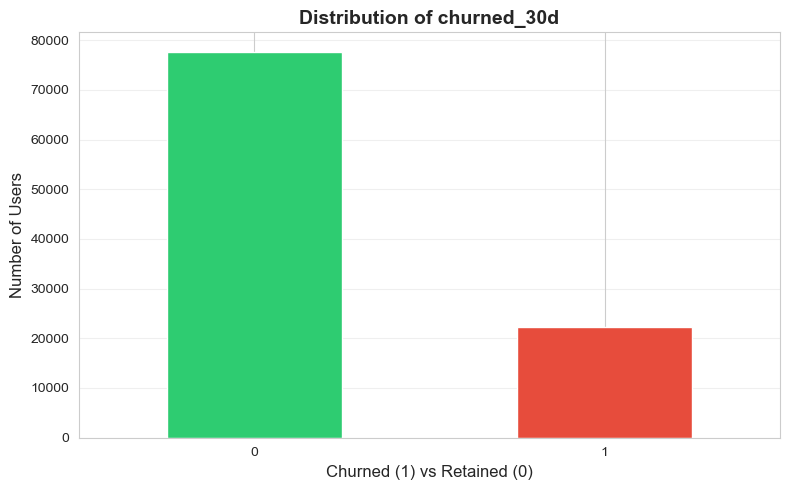

In [29]:
# ============================================================
# STEP 4: Understand the Target Variable
# ============================================================
# The target is what we're trying to predict
# In this case: Will a user churn (leave) or not?

print("\n3. Target Variable Analysis:")
print("-" * 60)

if TARGET_COLUMN in df.columns:
    print(f"✅ Target column '{TARGET_COLUMN}' found!")
    
    # Count how many of each value
    print(f"\n📊 Distribution of {TARGET_COLUMN}:")
    target_counts = df[TARGET_COLUMN].value_counts()
    print(target_counts)
    
    # Calculate percentages
    print(f"\n📈 Percentage distribution:")
    target_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100
    print(target_pct.round(2))
    
    # Calculate churn rate
    churn_rate = df[TARGET_COLUMN].mean() * 100
    print(f"\n🎯 Overall churn rate: {churn_rate:.2f}%")
    
    # Visualize the distribution
    plt.figure(figsize=(8, 5))
    df[TARGET_COLUMN].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
    plt.title(f'Distribution of {TARGET_COLUMN}', fontsize=14, fontweight='bold')
    plt.xlabel('Churned (1) vs Retained (0)', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"❌ Target column '{TARGET_COLUMN}' not found!")
    print("Available columns:", df.columns.tolist())

# ============================================================
# EXPLANATION:
# ============================================================
# The target variable is binary:
# - 0 = User did NOT churn (retained)
# - 1 = User DID churn (left)
#
# This is a CLASSIFICATION problem (predicting categories, not numbers)
#
# If the classes are imbalanced (e.g., 80% retained, 20% churned),
# we need special techniques to handle this (we'll cover this later)

## 3️⃣ Data Validation (Milestone 2)

**Why this matters:**
- **Garbage in, garbage out**: Bad data = bad models
- Catching issues early saves time later
- FAANG companies spend 60-80% of time on data validation
- Prevents costly mistakes in production

**What we're doing:**
- Checking for duplicates (data integrity)
- Finding missing values (completeness)
- Validating data types (correctness)
- Checking for impossible values (domain constraints)
- Ensuring temporal consistency (no time travel!)
- Validating the target variable (what we're predicting)

**This is like a quality control check before building anything!**

In [30]:
# ============================================================
# VALIDATION STEP 1: Check for Duplicates
# ============================================================
# Duplicates can cause problems:
# - They can make our model think some patterns are more important than they are
# - They can lead to data leakage (same user appearing in both train and test)

print("🔍 DATA VALIDATION CHECKS")
print("=" * 60)

print("\n1️⃣ Checking for Duplicates:")
print("-" * 60)

# Check for completely identical rows
full_duplicates = df.duplicated().sum()
print(f"   Full row duplicates: {full_duplicates}")

# Check for duplicate user-snapshot combinations
# In our case, each row should be unique (user_id, snapshot_date)
key_columns = ["user_id", "snapshot_date"]
if all(col in df.columns for col in key_columns):
    key_duplicates = df.duplicated(subset=key_columns).sum()
    print(f"   Duplicate (user_id, snapshot_date): {key_duplicates}")
    
    if key_duplicates == 0:
        print("   ✅ No duplicates found - data integrity is good!")
    else:
        print(f"   ⚠️ Found {key_duplicates} duplicates - need to investigate!")
else:
    print("   ⚠️ Key columns not found for duplicate check")

# ============================================================
# EXPLANATION:
# ============================================================
# Why check duplicates?
# - If the same user appears twice with the same snapshot_date, that's a problem
# - It means our data grain (level of detail) is wrong
# - In our case: 1 row = 1 user at 1 point in time (snapshot_date)
# 
# If we find duplicates, we need to decide:
# - Keep the first occurrence?
# - Keep the last occurrence?
# - Aggregate them somehow?
# - Investigate why they exist?

🔍 DATA VALIDATION CHECKS

1️⃣ Checking for Duplicates:
------------------------------------------------------------
   Full row duplicates: 0
   Duplicate (user_id, snapshot_date): 0
   ✅ No duplicates found - data integrity is good!



2️⃣ Checking for Missing Values:
------------------------------------------------------------
   ⚠️ Found missing values in 2 columns:

   Top columns with missing values:
      - payment_type: 51.82% missing
      - region: 44.75% missing


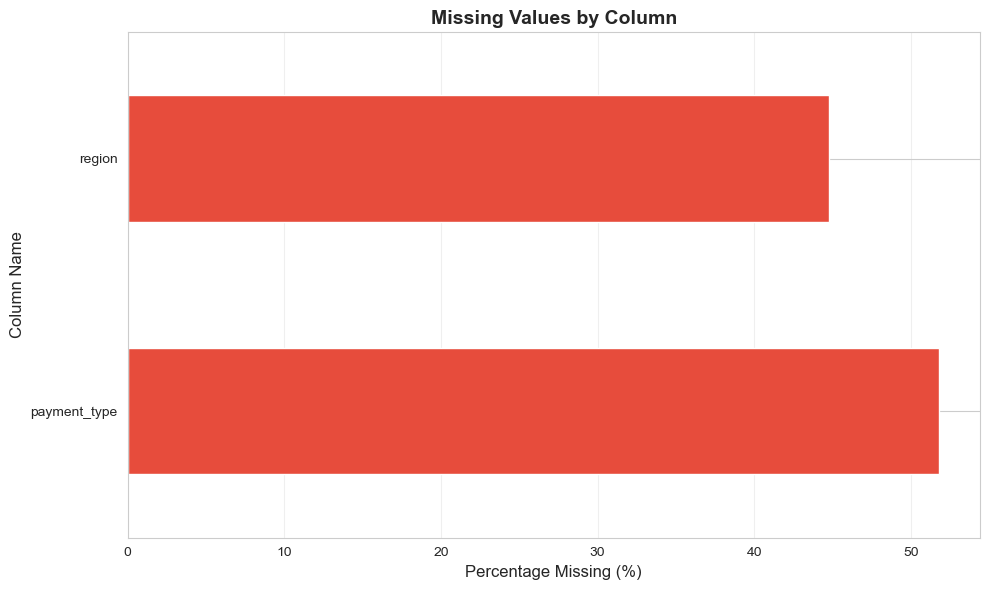

In [31]:
# ============================================================
# VALIDATION STEP 2: Check for Missing Values
# ============================================================
# Missing values are like holes in our data
# We need to know about them before we can fix them

print("\n2️⃣ Checking for Missing Values:")
print("-" * 60)

# Calculate percentage of missing values for each column
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) == 0:
    print("   ✅ No missing values found - perfect!")
else:
    print(f"   ⚠️ Found missing values in {len(missing_pct)} columns:")
    print("\n   Top columns with missing values:")
    for col, pct in missing_pct.head(10).items():
        print(f"      - {col}: {pct:.2f}% missing")
    
    # Visualize missing values
    if len(missing_pct) > 0:
        plt.figure(figsize=(10, 6))
        missing_pct.head(15).plot(kind='barh', color='#e74c3c')
        plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
        plt.xlabel('Percentage Missing (%)', fontsize=12)
        plt.ylabel('Column Name', fontsize=12)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

# ============================================================
# EXPLANATION:
# ============================================================
# Missing values can be:
# 1. Missing at Random (MAR) - no pattern, just random
# 2. Missing Not at Random (MNAR) - there IS a pattern (e.g., users with low engagement don't report data)
# 3. Structurally Missing - expected (e.g., "payment_type" only exists for paid users)
#
# We'll handle missing values later in preprocessing, but we need to know about them now!

In [32]:
# ============================================================
# VALIDATION STEP 3: Identify Column Types
# ============================================================
# We need to know which columns are numbers vs categories
# This determines how we'll process them later

print("\n3️⃣ Identifying Column Types:")
print("-" * 60)

# Separate columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

# Remove target and ID columns from feature lists
if TARGET_COLUMN in numeric_cols:
    numeric_cols.remove(TARGET_COLUMN)
if 'user_id' in numeric_cols:
    numeric_cols.remove('user_id')

print(f"   📊 Numeric columns ({len(numeric_cols)}):")
print(f"      {', '.join(numeric_cols[:10])}{'...' if len(numeric_cols) > 10 else ''}")

print(f"\n   📝 Categorical columns ({len(categorical_cols)}):")
print(f"      {', '.join(categorical_cols[:10])}{'...' if len(categorical_cols) > 10 else ''}")

print(f"\n   📅 Datetime columns ({len(datetime_cols)}):")
print(f"      {', '.join(datetime_cols)}")

print(f"\n   🎯 Target column: {TARGET_COLUMN}")

# ============================================================
# EXPLANATION:
# ============================================================
# Column types determine how we process them:
# - Numeric: Can do math (mean, sum, etc.). May need scaling.
# - Categorical: Text/categories. Need encoding (convert to numbers).
# - Datetime: Dates/times. Can extract features (day of week, month, etc.).
#
# We separate them because:
# - Different preprocessing steps for each type
# - Different ways to handle missing values
# - Different ways to visualize them


3️⃣ Identifying Column Types:
------------------------------------------------------------
   📊 Numeric columns (11):
      tenure_days, sessions_7d, utterances_7d, voice_share_7d, avg_latency_ms_7d, p95_latency_ms_7d, error_rate_7d, avg_input_tokens_7d, avg_output_tokens_7d, tokens_per_second_7d...

   📝 Categorical columns (13):
      age_bucket, gender, region, language, subscription_status, payment_type, utterance_type, device_type, device_subtype, device_model...

   📅 Datetime columns (1):
      snapshot_date

   🎯 Target column: churned_30d


In [33]:
# ============================================================
# VALIDATION STEP 4: Check for Impossible Values
# ============================================================
# Some values just don't make sense (negative counts, percentages > 100%, etc.)

print("\n4️⃣ Checking for Impossible Values:")
print("-" * 60)

issues_found = []

# Check numeric columns for negative values (where negative doesn't make sense)
for col in numeric_cols:
    if col in ['sessions_7d', 'utterances_7d', 'tenure_days']:  # These should never be negative
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            issues_found.append(f"   ❌ {col}: {negative_count} negative values found")
        else:
            print(f"   ✅ {col}: No negative values")

# Check rate/percentage columns (should be between 0 and 1)
rate_columns = [col for col in numeric_cols if any(word in col.lower() for word in ['rate', 'share', 'pct'])]
for col in rate_columns:
    out_of_range = ((df[col] < 0) | (df[col] > 1)).sum()
    if out_of_range > 0:
        issues_found.append(f"   ❌ {col}: {out_of_range} values outside [0, 1]")
    else:
        print(f"   ✅ {col}: All values in valid range [0, 1]")

if not issues_found:
    print("   ✅ No impossible values found!")
else:
    print("\n   ⚠️ Issues found:")
    for issue in issues_found:
        print(issue)

# ============================================================
# EXPLANATION:
# ============================================================
# Domain knowledge matters here!
# - Sessions can't be negative
# - Percentages should be between 0% and 100% (0 and 1 as decimals)
# - Age can't be negative
#
# These checks catch data entry errors, calculation bugs, or data pipeline issues


4️⃣ Checking for Impossible Values:
------------------------------------------------------------
   ✅ tenure_days: No negative values
   ✅ sessions_7d: No negative values
   ✅ utterances_7d: No negative values
   ✅ voice_share_7d: All values in valid range [0, 1]
   ✅ error_rate_7d: All values in valid range [0, 1]
   ✅ pct_low_battery_7d: All values in valid range [0, 1]
   ✅ No impossible values found!


In [34]:
# ============================================================
# VALIDATION STEP 5: Temporal Consistency
# ============================================================
# Check that dates make sense (no time travel!)

print("\n5️⃣ Checking Temporal Consistency:")
print("-" * 60)

if 'snapshot_date' in df.columns:
    # Check for invalid dates
    invalid_dates = df['snapshot_date'].isna().sum()
    print(f"   Invalid/missing snapshot_date: {invalid_dates}")
    
    if 'signup_date' in df.columns:
        # Check that signup_date <= snapshot_date (users can't sign up in the future!)
        df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
        temporal_violations = (df['signup_date'] > df['snapshot_date']).sum()
        
        if temporal_violations == 0:
            print("   ✅ All signup dates are before snapshot dates (logical!)")
        else:
            print(f"   ❌ Found {temporal_violations} temporal violations (signup after snapshot)")
    else:
        print("   ℹ️ signup_date column not found - skipping temporal check")
else:
    print("   ℹ️ snapshot_date column not found")

# ============================================================
# EXPLANATION:
# ============================================================
# Temporal consistency means:
# - Dates should be in logical order
# - A user can't sign up AFTER we take a snapshot of them
# - Events should happen in chronological order
#
# Violations can indicate:
# - Data entry errors
# - Timezone issues
# - Data pipeline bugs


5️⃣ Checking Temporal Consistency:
------------------------------------------------------------
   Invalid/missing snapshot_date: 0
   ℹ️ signup_date column not found - skipping temporal check


In [35]:
# ============================================================
# VALIDATION STEP 6: Target Variable Validation
# ============================================================
# Make sure our target variable is ready for modeling

print("\n6️⃣ Validating Target Variable:")
print("-" * 60)

if TARGET_COLUMN in df.columns:
    # Check for missing target values
    missing_target = df[TARGET_COLUMN].isna().sum()
    print(f"   Missing target values: {missing_target}")
    
    # Check that target is binary (only 0 and 1)
    unique_values = sorted(df[TARGET_COLUMN].dropna().unique())
    print(f"   Unique target values: {unique_values}")
    
    if set(unique_values) == {0, 1}:
        print("   ✅ Target is binary (0 and 1 only) - perfect for classification!")
    else:
        print(f"   ⚠️ Target has unexpected values: {unique_values}")
    
    # Check class balance
    churn_rate = df[TARGET_COLUMN].mean()
    print(f"   Churn rate: {churn_rate:.2%}")
    
    if 0.1 <= churn_rate <= 0.9:
        print("   ✅ Classes are reasonably balanced")
    else:
        print("   ⚠️ Classes are imbalanced - we'll need special techniques")
        
else:
    print(f"   ❌ Target column '{TARGET_COLUMN}' not found!")

print("\n" + "=" * 60)
print("✅ DATA VALIDATION COMPLETE!")
print("=" * 60)

# ============================================================
# EXPLANATION:
# ============================================================
# Target variable validation ensures:
# 1. No missing values (we can't train on missing targets)
# 2. Correct format (binary: 0/1 for classification)
# 3. Reasonable class balance (not 99% one class, 1% the other)
#
# If classes are very imbalanced (e.g., 95% retained, 5% churned):
# - We might use class weights
# - We might use different evaluation metrics (precision/recall instead of accuracy)
# - We might use resampling techniques (SMOTE, undersampling, etc.)


6️⃣ Validating Target Variable:
------------------------------------------------------------
   Missing target values: 0
   Unique target values: [np.int64(0), np.int64(1)]
   ✅ Target is binary (0 and 1 only) - perfect for classification!
   Churn rate: 22.31%
   ✅ Classes are reasonably balanced

✅ DATA VALIDATION COMPLETE!


## 4️⃣ Exploratory Data Analysis (EDA)

**Why this matters:**
- **You can't model what you don't understand**
- EDA reveals patterns, relationships, and potential issues
- Helps us choose the right features and models
- Identifies outliers and anomalies
- Guides feature engineering decisions

**What we're doing:**
- Statistical summaries of all features
- Visualizing distributions
- Finding correlations between features
- Comparing churned vs retained users
- Statistical tests to confirm differences

**Think of EDA as detective work - we're looking for clues about what causes churn!**

In [36]:
# ============================================================
# EDA STEP 1: Statistical Summary of Numeric Features
# ============================================================
# This gives us a quick overview: mean, median, min, max, etc.

print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\n1️⃣ Statistical Summary of Numeric Features:")
print("-" * 60)
print("This shows us: mean, median, min, max, quartiles, etc.")
print("It helps us understand the 'typical' values and spot outliers\n")

# Get summary statistics
summary_stats = df[numeric_cols].describe().T
display(summary_stats)

# ============================================================
# EXPLANATION:
# ============================================================
# .describe() gives us:
# - count: How many non-null values
# - mean: Average value
# - std: Standard deviation (how spread out the data is)
# - min: Smallest value
# - 25%: First quartile (25% of values are below this)
# - 50%: Median (middle value, 50% above, 50% below)
# - 75%: Third quartile (75% of values are below this)
# - max: Largest value
#
# Red flags to watch for:
# - Huge difference between mean and median = skewed data
# - Very large std = high variability
# - Min/max that don't make sense = outliers or errors

📊 EXPLORATORY DATA ANALYSIS

1️⃣ Statistical Summary of Numeric Features:
------------------------------------------------------------
This shows us: mean, median, min, max, quartiles, etc.
It helps us understand the 'typical' values and spot outliers



,count,mean,std,min,25%,50%,75%,max
tenure_days,100000.00,374.37,210.41,5.00,193.00,374.00,558.00,740.00
sessions_7d,100000.00,3.67,2.14,0.00,2.00,3.00,5.00,13.00
utterances_7d,100000.00,6.98,4.50,0.00,3.00,6.00,10.00,28.00
voice_share_7d,100000.00,0.21,0.41,0.00,0.00,0.00,0.00,1.00
avg_latency_ms_7d,100000.00,558.02,186.46,0.00,467.58,570.36,670.15,1699.00
p95_latency_ms_7d,100000.00,681.80,239.43,0.00,558.26,694.75,831.82,2071.00
error_rate_7d,100000.00,0.04,0.09,0.00,0.00,0.00,0.00,1.00
avg_input_tokens_7d,100000.00,174.35,87.74,0.00,95.25,191.36,238.58,693.00
avg_output_tokens_7d,100000.00,207.02,106.21,0.00,130.50,208.00,277.15,958.00
tokens_per_second_7d,100000.00,346.94,129.04,0.00,279.19,364.53,427.49,4100.00



2️⃣ Comparing Churned vs Retained Users:
------------------------------------------------------------
This tells us which features might predict churn

   Churned users: 22,315
   Retained users: 77,685



,Retained (Mean),Churned (Mean),Difference,% Difference
sessions_7d,3.70,3.58,-0.12,-3.21
utterances_7d,7.01,6.86,-0.15,-2.17
avg_latency_ms_7d,553.19,574.86,21.68,3.92
p95_latency_ms_7d,675.72,702.98,27.26,4.03
error_rate_7d,0.03,0.05,0.02,60.05
pct_low_battery_7d,0.06,0.06,0.00,3.17


/var/folders/nw/45hwdkf56p76zr97txg1hjr40000gn/T/ipykernel_9484/1576649201.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Retained', 'Churned'], showfliers=False)
/var/folders/nw/45hwdkf56p76zr97txg1hjr40000gn/T/ipykernel_9484/1576649201.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Retained', 'Churned'], showfliers=False)
/var/folders/nw/45hwdkf56p76zr97txg1hjr40000gn/T/ipykernel_9484/1576649201.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Retained', 'Churned'], showfliers=False)
/var/folders/nw/

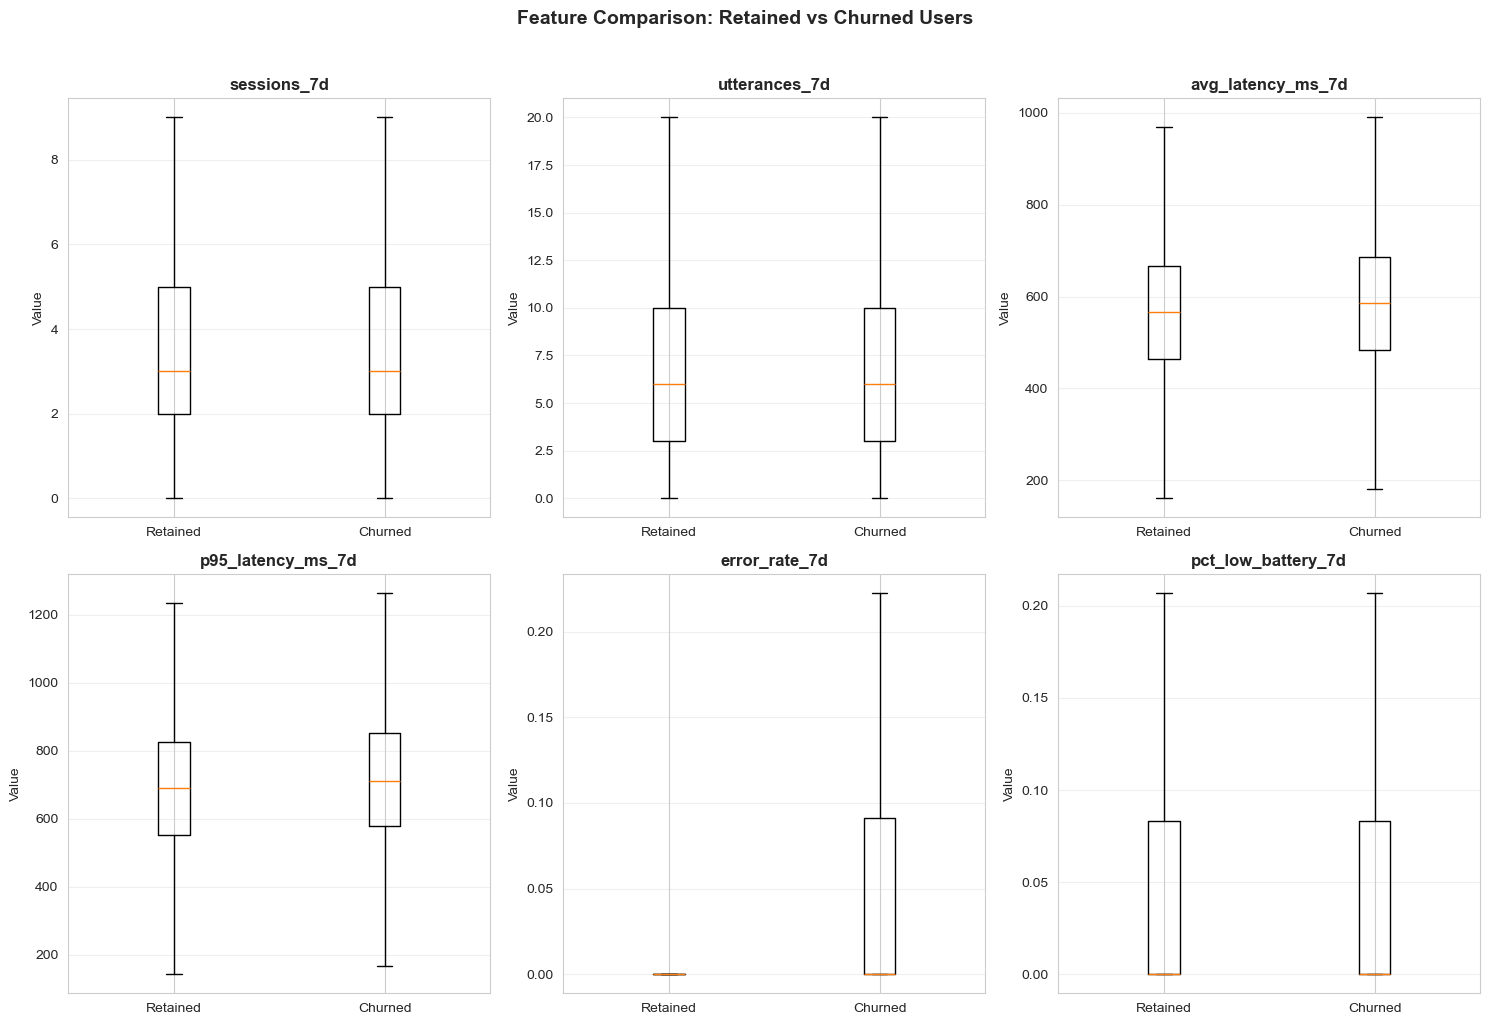

In [37]:
# ============================================================
# EDA STEP 2: Compare Churned vs Retained Users
# ============================================================
# This is the KEY question: What's different about users who churn?

print("\n2️⃣ Comparing Churned vs Retained Users:")
print("-" * 60)
print("This tells us which features might predict churn\n")

if TARGET_COLUMN in df.columns:
    # Split data by churn status
    churned = df[df[TARGET_COLUMN] == 1]
    retained = df[df[TARGET_COLUMN] == 0]
    
    print(f"   Churned users: {len(churned):,}")
    print(f"   Retained users: {len(retained):,}\n")
    
    # Compare means for key numeric features
    key_features = ['sessions_7d', 'utterances_7d', 'avg_latency_ms_7d', 
                     'p95_latency_ms_7d', 'error_rate_7d', 'pct_low_battery_7d']
    key_features = [f for f in key_features if f in numeric_cols]
    
    comparison = pd.DataFrame({
        'Retained (Mean)': [retained[f].mean() for f in key_features],
        'Churned (Mean)': [churned[f].mean() for f in key_features],
    }, index=key_features)
    
    # Calculate difference
    comparison['Difference'] = comparison['Churned (Mean)'] - comparison['Retained (Mean)']
    comparison['% Difference'] = (comparison['Difference'] / comparison['Retained (Mean)']) * 100
    
    display(comparison.round(2))
    
    # Visualize the comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(key_features[:6]):
        ax = axes[idx]
        data_to_plot = [retained[feature].dropna(), churned[feature].dropna()]
        ax.boxplot(data_to_plot, labels=['Retained', 'Churned'], showfliers=False)
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Comparison: Retained vs Churned Users', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ============================================================
# EXPLANATION:
# ============================================================
# This comparison is CRUCIAL because:
# - If churned users have different feature values, those features might predict churn
# - For example: If churned users have higher latency, latency might be a predictor
# - Boxplots show us the distribution (not just the mean)
# - We can see if there's overlap or clear separation
#
# Good predictors = features where churned and retained users are clearly different


3️⃣ Correlation Analysis:
------------------------------------------------------------
Correlation ranges from -1 to +1:
  +1 = Perfect positive correlation (both increase together)
  -1 = Perfect negative correlation (one increases, other decreases)
   0 = No correlation (independent)

Top features correlated with churn:
error_rate_7d           0.09
avg_latency_ms_7d       0.05
p95_latency_ms_7d       0.05
avg_output_tokens_7d    0.04
avg_input_tokens_7d     0.03
sessions_7d            -0.02
tokens_per_second_7d    0.02
utterances_7d          -0.01
pct_low_battery_7d      0.01
tenure_days            -0.00


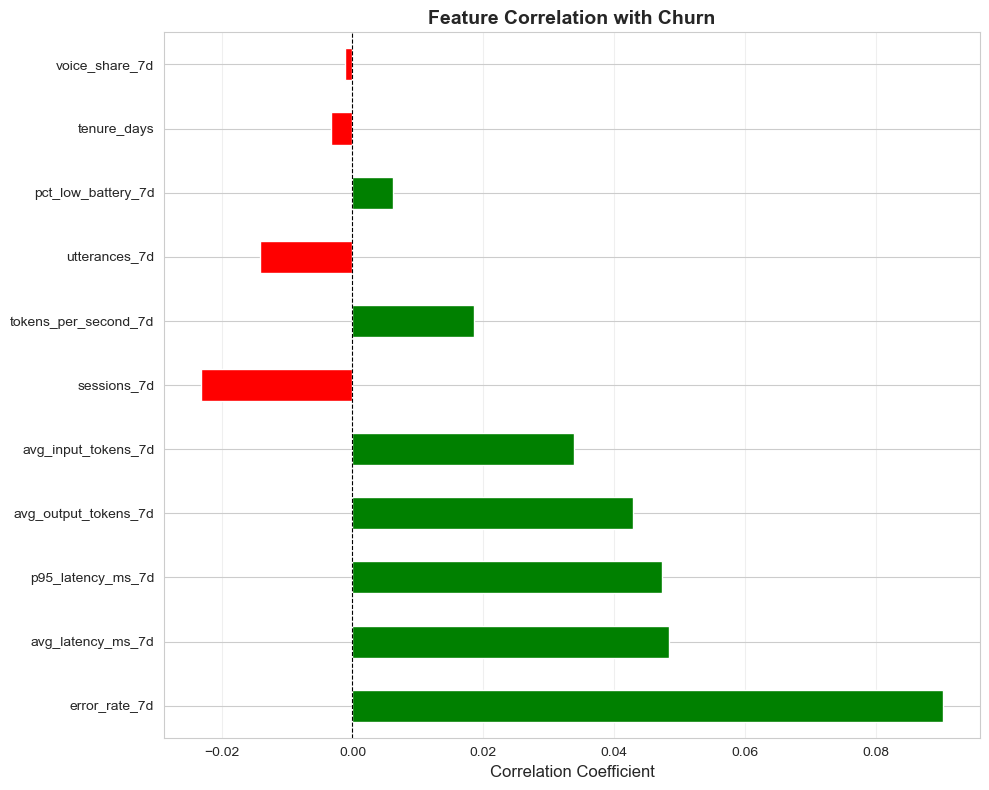

In [38]:
# ============================================================
# EDA STEP 3: Correlation Analysis
# ============================================================
# Correlation tells us how features relate to each other
# High correlation = features move together (might be redundant)

print("\n3️⃣ Correlation Analysis:")
print("-" * 60)
print("Correlation ranges from -1 to +1:")
print("  +1 = Perfect positive correlation (both increase together)")
print("  -1 = Perfect negative correlation (one increases, other decreases)")
print("   0 = No correlation (independent)\n")

# Calculate correlation matrix
correlation_matrix = df[numeric_cols + [TARGET_COLUMN]].corr()

# Visualize correlation with target
if TARGET_COLUMN in correlation_matrix.columns:
    target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
    
    print("Top features correlated with churn:")
    print(target_corr.head(10).to_string())
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_features = target_corr.head(15)
    colors = ['red' if x < 0 else 'green' for x in top_features.values]
    top_features.plot(kind='barh', color=colors)
    plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# EXPLANATION:
# ============================================================
# Correlation with target is important because:
# - High positive correlation = feature increases when churn increases
# - High negative correlation = feature decreases when churn increases
# - Features with strong correlation (positive or negative) are likely good predictors
#
# But be careful:
# - Correlation doesn't mean causation!
# - Very high correlation between features (multicollinearity) can be a problem
# - Some relationships are non-linear (correlation won't catch them)

In [39]:
# ============================================================
# FEATURE ENGINEERING: Create New Features
# ============================================================
# We'll create a copy to avoid modifying the original data
# This is a best practice - always keep original data intact!

print("🔧 FEATURE ENGINEERING")
print("=" * 60)

df_features = df.copy()

print("\n1️⃣ Creating Derived Features:")
print("-" * 60)

# Feature 1: Latency per session (efficiency metric)
if 'sum_latency_ms_7d' in df_features.columns and 'sessions_7d' in df_features.columns:
    df_features['latency_per_session'] = (
        df_features['sum_latency_ms_7d'] / 
        df_features['sessions_7d'].replace(0, np.nan)
    ).fillna(0)
    print("   ✅ Created: latency_per_session (total latency / sessions)")

# Feature 2: Tokens per utterance (engagement depth)
if 'sum_out_tokens_7d' in df_features.columns and 'utterances_7d' in df_features.columns:
    df_features['tokens_per_utterance'] = (
        df_features['sum_out_tokens_7d'] / 
        df_features['utterances_7d'].replace(0, np.nan)
    ).fillna(0)
    print("   ✅ Created: tokens_per_utterance (total tokens / utterances)")

# Feature 3: High latency flag (binary feature)
if 'p95_latency_ms_7d' in df_features.columns:
    # Define "high latency" as above 75th percentile
    latency_threshold = df_features['p95_latency_ms_7d'].quantile(0.75)
    df_features['high_latency_flag'] = (df_features['p95_latency_ms_7d'] > latency_threshold).astype(int)
    print(f"   ✅ Created: high_latency_flag (p95 latency > {latency_threshold:.0f}ms)")

# Feature 4: Low engagement flag
if 'sessions_7d' in df_features.columns:
    engagement_threshold = df_features['sessions_7d'].quantile(0.25)
    df_features['low_engagement_flag'] = (df_features['sessions_7d'] < engagement_threshold).astype(int)
    print(f"   ✅ Created: low_engagement_flag (sessions < {engagement_threshold:.1f})")

print(f"\n   📊 Total features now: {df_features.shape[1]} (started with {df.shape[1]})")

# ============================================================
# EXPLANATION:
# ============================================================
# Feature engineering is about creating new information from existing data:
# 
# 1. Ratio features: Combine two features (e.g., latency/session = efficiency)
# 2. Binary flags: Convert continuous to binary (e.g., "high latency" yes/no)
# 3. Interaction features: Multiply or combine features (e.g., latency × errors)
# 4. Binning: Convert continuous to categories (e.g., age groups)
#
# Why create new features?
# - Sometimes the relationship isn't in the raw data, but in combinations
# - Models can learn these, but giving them explicitly helps
# - Domain knowledge guides us (e.g., "high latency is bad" → create flag)
#
# Best practices:
# - Always create a copy first (don't modify original)
# - Document what each feature means
# - Test if new features improve model performance

🔧 FEATURE ENGINEERING

1️⃣ Creating Derived Features:
------------------------------------------------------------
   ✅ Created: high_latency_flag (p95 latency > 832ms)
   ✅ Created: low_engagement_flag (sessions < 2.0)

   📊 Total features now: 29 (started with 27)


## 6️⃣ Data Preprocessing

**Why this matters:**
- Machine learning models need clean, formatted data
- Different algorithms have different requirements
- Proper preprocessing prevents errors and improves performance
- This is where we handle missing values, scaling, encoding, etc.

**What we're doing:**
- Separating features from target
- Splitting into train/test sets
- Handling missing values
- Scaling numeric features
- Encoding categorical features
- Creating a preprocessing pipeline

**This prepares our data for the machine learning models!**

In [40]:
# ============================================================
# PREPROCESSING STEP 1: Prepare Features and Target
# ============================================================

print("🔄 DATA PREPROCESSING")
print("=" * 60)

# Update numeric and categorical columns (include new features)
numeric_cols_updated = df_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_updated = df_features.select_dtypes(include=['object']).columns.tolist()

# Remove target and ID columns
if TARGET_COLUMN in numeric_cols_updated:
    numeric_cols_updated.remove(TARGET_COLUMN)
if 'user_id' in numeric_cols_updated:
    numeric_cols_updated.remove('user_id')
if 'snapshot_date' in categorical_cols_updated:
    categorical_cols_updated.remove('snapshot_date')

# Select only columns that exist in dataframe
numeric_cols_updated = [c for c in numeric_cols_updated if c in df_features.columns]
categorical_cols_updated = [c for c in categorical_cols_updated if c in df_features.columns]

print(f"\n📊 Numeric features: {len(numeric_cols_updated)}")
print(f"📝 Categorical features: {len(categorical_cols_updated)}")

# Separate features (X) and target (y)
X = df_features[numeric_cols_updated + categorical_cols_updated]
y = df_features[TARGET_COLUMN]

print(f"\n✅ Features (X) shape: {X.shape}")
print(f"✅ Target (y) shape: {y.shape}")

# ============================================================
# EXPLANATION:
# ============================================================
# X = Features (what we use to make predictions)
# y = Target (what we're trying to predict)
#
# We separate them because:
# - Models learn from X to predict y
# - We need to process X and y differently
# - We'll split X and y into train/test sets

🔄 DATA PREPROCESSING

📊 Numeric features: 13
📝 Categorical features: 13

✅ Features (X) shape: (100000, 26)
✅ Target (y) shape: (100000,)


In [41]:
# ============================================================
# PREPROCESSING STEP 2: Train/Test Split
# ============================================================
# CRITICAL: We must split BEFORE any preprocessing that uses statistics
# Otherwise we get "data leakage" (test data influences training)

print("\n2️⃣ Train/Test Split:")
print("-" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% for testing, 80% for training
    random_state=RANDOM_STATE,  # For reproducibility
    stratify=y                # Keep same churn rate in both sets
)

print(f"   Training set: {X_train.shape[0]:,} samples")
print(f"   Test set: {X_test.shape[0]:,} samples")
print(f"   Training churn rate: {y_train.mean():.2%}")
print(f"   Test churn rate: {y_test.mean():.2%}")

# ============================================================
# EXPLANATION:
# ============================================================
# Why split the data?
# - Train set: Used to teach the model (80%)
# - Test set: Used to evaluate the model (20%) - NEVER used during training!
#
# Why stratify?
# - Ensures both sets have same proportion of churned/retained users
# - Prevents one set from having all churned users and other having all retained
#
# Why random_state?
# - Makes the split reproducible (same split every time)
# - Important for comparing different models fairly
#
# CRITICAL RULE: Never look at test set until final evaluation!
# This prevents overfitting (model memorizing test data)


2️⃣ Train/Test Split:
------------------------------------------------------------
   Training set: 80,000 samples
   Test set: 20,000 samples
   Training churn rate: 22.31%
   Test churn rate: 22.31%


In [42]:
# ============================================================
# PREPROCESSING STEP 3: Create Preprocessing Pipeline
# ============================================================
# Pipelines chain multiple steps together
# This is a FAANG best practice - clean, reusable, testable

print("\n3️⃣ Creating Preprocessing Pipeline:")
print("-" * 60)

# Step 1: Handle missing values in numeric columns
# Strategy: Fill with median (middle value) - robust to outliers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # Scale to mean=0, std=1
])

# Step 2: Handle missing values and encode categorical columns
# Strategy: Fill with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Step 3: Combine both transformers
# Apply numeric transformer to numeric columns, categorical to categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols_updated),
        ('cat', categorical_transformer, categorical_cols_updated)
    ]
)

print("   ✅ Pipeline created with:")
print("      - Numeric: Imputation (median) + Scaling (standardization)")
print("      - Categorical: Imputation (most frequent) + One-hot encoding")

# Fit pipeline on training data only!
print("\n   🔄 Fitting pipeline on training data...")
preprocessor.fit(X_train)
print("   ✅ Pipeline fitted!")

# Transform both train and test
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n   📊 Processed training set shape: {X_train_processed.shape}")
print(f"   📊 Processed test set shape: {X_test_processed.shape}")

# ============================================================
# EXPLANATION:
# ============================================================
# Why use pipelines?
# 1. Clean code: All preprocessing in one place
# 2. Prevents leakage: Fit on train, transform test
# 3. Reusable: Can apply to new data easily
# 4. Testable: Can test each step independently
#
# What each step does:
# - Imputation: Fills missing values (can't have NaN in models)
# - Scaling: Makes all numeric features same scale (0-1 range)
#   - Why? Some algorithms (like logistic regression) need this
#   - Prevents features with large values from dominating
# - One-hot encoding: Converts categories to binary columns
#   - Example: "device_type" = ["phone", "laptop", "tablet"]
#   - Becomes: device_type_phone, device_type_laptop, device_type_tablet
#
# CRITICAL: Fit on train, transform test!
# - If we fit on full dataset, we're using test data info = leakage!


3️⃣ Creating Preprocessing Pipeline:
------------------------------------------------------------
   ✅ Pipeline created with:
      - Numeric: Imputation (median) + Scaling (standardization)
      - Categorical: Imputation (most frequent) + One-hot encoding

   🔄 Fitting pipeline on training data...
   ✅ Pipeline fitted!

   📊 Processed training set shape: (80000, 78)
   📊 Processed test set shape: (20000, 78)


### 6.1️⃣ Class Imbalance Analysis: Do We Need Sampling?

**Why this matters:**
- If classes are very imbalanced (e.g., 90% retained, 10% churned), models might ignore the minority class
- Sampling techniques can balance the classes
- But sampling isn't always needed - sometimes class weights work better

**What we're checking:**
- Current class distribution
- Imbalance ratio
- Whether sampling is recommended

In [ ]:
# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================

print("⚖️ CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# Check class distribution
if TARGET_COLUMN in df_features.columns:
    class_counts = df_features[TARGET_COLUMN].value_counts()
    class_pct = df_features[TARGET_COLUMN].value_counts(normalize=True) * 100
    
    print("\n📊 Class Distribution:")
    print("-" * 60)
    for class_val, count in class_counts.items():
        pct = class_pct[class_val]
        label = "Churned" if class_val == 1 else "Retained"
        print(f"   {label} ({class_val}): {count:,} ({pct:.2f}%)")
    
    # Calculate imbalance ratio
    minority_class = class_counts.min()
    majority_class = class_counts.max()
    imbalance_ratio = majority_class / minority_class
    
    print(f"\n📈 Imbalance Ratio: {imbalance_ratio:.2f}:1")
    print("   (Ratio of majority to minority class)")
    
    # Visualize
    plt.figure(figsize=(10, 5))
    
    # Subplot 1: Count
    plt.subplot(1, 2, 1)
    class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
    plt.title('Class Distribution (Counts)', fontweight='bold')
    plt.xlabel('Class (0=Retained, 1=Churned)')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    # Subplot 2: Percentage
    plt.subplot(1, 2, 2)
    class_pct.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
    plt.title('Class Distribution (Percentages)', fontweight='bold')
    plt.xlabel('Class (0=Retained, 1=Churned)')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Determine if sampling is needed
    print("\n🔍 Sampling Recommendation:")
    print("-" * 60)
    
    if imbalance_ratio < 2:
        print("   ✅ Classes are well-balanced")
        print("   💡 Recommendation: No sampling needed")
        print("   💡 Use class_weight='balanced' in models if needed")
        NEED_SAMPLING = False
    elif imbalance_ratio < 5:
        print("   ⚠️ Moderate imbalance detected")
        print("   💡 Recommendation: Consider class weights OR light sampling")
        print("   💡 Try both and compare results")
        NEED_SAMPLING = "optional"
    else:
        print("   ⚠️ Severe imbalance detected")
        print("   💡 Recommendation: Sampling recommended")
        print("   💡 Options: SMOTE (oversampling), undersampling, or class weights")
        NEED_SAMPLING = True
    
    print(f"\n   Current imbalance ratio: {imbalance_ratio:.2f}:1")
    
else:
    print("   ⚠️ Target column not found - cannot analyze class imbalance")
    NEED_SAMPLING = False

# ============================================================
# EXPLANATION:
# ============================================================
# Class Imbalance:
# - Occurs when one class has many more samples than another
# - Example: 90% retained, 10% churned = 9:1 imbalance ratio
#
# Why it's a problem:
# - Models might predict majority class all the time
# - High accuracy but poor recall for minority class
# - Model doesn't learn to distinguish classes
#
# Solutions:
# 1. Class weights: Give more importance to minority class (simple, often works)
# 2. Oversampling: Create more minority class samples (SMOTE, ADASYN)
# 3. Undersampling: Remove some majority class samples (risky - lose data)
# 4. Combination: Both oversample and undersample
#
# Rule of thumb:
# - Ratio < 2:1 → No sampling needed
# - Ratio 2:1 to 5:1 → Optional sampling
# - Ratio > 5:1 → Sampling recommended

In [ ]:
# ============================================================
# APPLY SAMPLING IF NEEDED
# ============================================================
# We'll use SMOTE (Synthetic Minority Oversampling Technique) if needed

if NEED_SAMPLING == True:
    print("\n🔄 APPLYING SAMPLING")
    print("=" * 60)
    
    try:
        from imblearn.over_sampling import SMOTE
        
        print("\n   Using SMOTE (Synthetic Minority Oversampling Technique)")
        print("   This creates synthetic samples of the minority class")
        
        # Apply SMOTE to training data only!
        # CRITICAL: Never apply to test data - that's data leakage!
        smote = SMOTE(random_state=RANDOM_STATE)
        
        print(f"\n   Before SMOTE:")
        print(f"      Training set: {X_train_processed.shape}")
        print(f"      Class distribution: {pd.Series(y_train).value_counts().to_dict()}")
        
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
        
        print(f"\n   After SMOTE:")
        print(f"      Training set: {X_train_balanced.shape}")
        print(f"      Class distribution: {pd.Series(y_train_balanced).value_counts().to_dict()}")
        
        # Update training data
        X_train_processed = X_train_balanced
        y_train = y_train_balanced
        
        print("\n   ✅ Sampling applied successfully!")
        
    except ImportError:
        print("   ⚠️ imbalanced-learn library not installed")
        print("   💡 Install with: pip install imbalanced-learn")
        print("   💡 For now, we'll use class weights in models instead")
        NEED_SAMPLING = False
        
elif NEED_SAMPLING == "optional":
    print("\n💡 OPTIONAL SAMPLING")
    print("=" * 60)
    print("   Moderate imbalance detected - sampling is optional")
    print("   💡 We'll proceed without sampling")
    print("   💡 Models will use class_weight='balanced' instead")
    
else:
    print("\n✅ NO SAMPLING NEEDED")
    print("=" * 60)
    print("   Classes are well-balanced")
    print("   💡 Proceeding without sampling")

# ============================================================
# EXPLANATION:
# ============================================================
# SMOTE (Synthetic Minority Oversampling Technique):
# - Creates new synthetic samples for minority class
# - Doesn't just duplicate - creates new combinations
# - Works by finding nearest neighbors and creating interpolations
#
# Why only on training data?
# - Test data should represent real-world distribution
# - If we balance test data, we're not testing on realistic data
# - This would give misleading performance metrics
#
# Alternative: class_weight='balanced'
# - Doesn't create new samples
# - Just gives more weight to minority class during training
# - Often works just as well, simpler to implement

### 6.2️⃣ Scaling Technique Comparison

**Why this matters:**
- Different scaling methods work better for different data distributions
- Some algorithms are sensitive to feature scale
- Choosing the right scaler can improve model performance

**What we're comparing:**
- StandardScaler (mean=0, std=1) - good for normal distributions
- MinMaxScaler (0-1 range) - good for bounded data
- RobustScaler (median-based) - good for data with outliers

In [ ]:
# ============================================================
# SCALING TECHNIQUE COMPARISON
# ============================================================

print("📏 SCALING TECHNIQUE ANALYSIS")
print("=" * 60)

from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Prepare numeric data for comparison (before any scaling)
# Use training data only to avoid leakage
X_train_numeric_raw = X_train[numeric_cols_updated].fillna(X_train[numeric_cols_updated].median())

print("\n1️⃣ Comparing Scaling Techniques:")
print("-" * 60)

# Apply different scalers
scalers = {
    'StandardScaler (Z-score)': StandardScaler(),
    'MinMaxScaler (0-1)': MinMaxScaler(),
    'RobustScaler (Median-based)': RobustScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaler.fit(X_train_numeric_raw)
    scaled = scaler.transform(X_train_numeric_raw)
    scaled_data[name] = scaled

# Compare statistics for a sample feature
sample_feature_idx = 0
sample_feature_name = numeric_cols_updated[sample_feature_idx]

print(f"\n   Sample Feature: {sample_feature_name}")
print(f"   Original statistics:")
print(f"      Mean: {X_train_numeric_raw.iloc[:, sample_feature_idx].mean():.2f}")
print(f"      Std:  {X_train_numeric_raw.iloc[:, sample_feature_idx].std():.2f}")
print(f"      Min:  {X_train_numeric_raw.iloc[:, sample_feature_idx].min():.2f}")
print(f"      Max:  {X_train_numeric_raw.iloc[:, sample_feature_idx].max():.2f}")

print(f"\n   After scaling:")
for name, scaled in scaled_data.items():
    print(f"      {name}:")
    print(f"         Mean: {scaled[:, sample_feature_idx].mean():.2f}")
    print(f"         Std:  {scaled[:, sample_feature_idx].std():.2f}")
    print(f"         Min:  {scaled[:, sample_feature_idx].min():.2f}")
    print(f"         Max:  {scaled[:, sample_feature_idx].max():.2f}")

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Original
axes[0].hist(X_train_numeric_raw.iloc[:, sample_feature_idx], bins=50, color='gray', alpha=0.7)
axes[0].set_title(f'Original: {sample_feature_name}', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# StandardScaler
axes[1].hist(scaled_data['StandardScaler (Z-score)'][:, sample_feature_idx], bins=50, color='blue', alpha=0.7)
axes[1].set_title('StandardScaler (Mean=0, Std=1)', fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

# MinMaxScaler
axes[2].hist(scaled_data['MinMaxScaler (0-1)'][:, sample_feature_idx], bins=50, color='green', alpha=0.7)
axes[2].set_title('MinMaxScaler (Range: 0-1)', fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

# RobustScaler
axes[3].hist(scaled_data['RobustScaler (Median-based)'][:, sample_feature_idx], bins=50, color='red', alpha=0.7)
axes[3].set_title('RobustScaler (Median-based)', fontweight='bold')
axes[3].set_xlabel('Value')
axes[3].set_ylabel('Frequency')
axes[3].grid(alpha=0.3)

plt.suptitle('Scaling Technique Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Recommendation
print("\n💡 Scaling Recommendation:")
print("-" * 60)
print("   StandardScaler: Best for normal distributions, most common choice")
print("   MinMaxScaler: Best when you need bounded range (0-1), good for neural networks")
print("   RobustScaler: Best when you have outliers (uses median instead of mean)")
print("\n   ✅ We'll use StandardScaler (most versatile and commonly used)")

# ============================================================
# EXPLANATION:
# ============================================================
# Why scale features?
# - Some algorithms (like Logistic Regression, SVM, Neural Networks) are sensitive to scale
# - Features with large values can dominate the model
# - Scaling puts all features on the same "playing field"
#
# StandardScaler (Z-score normalization):
# - Transforms: (x - mean) / std
# - Result: Mean = 0, Std = 1
# - Good for: Normal distributions, most algorithms
# - Sensitive to: Outliers (outliers affect mean and std)
#
# MinMaxScaler:
# - Transforms: (x - min) / (max - min)
# - Result: Range = 0 to 1
# - Good for: Bounded data, neural networks
# - Sensitive to: Outliers (outliers become 0 or 1)
#
# RobustScaler:
# - Uses median and IQR instead of mean and std
# - Result: Median = 0, IQR-based scaling
# - Good for: Data with outliers
# - Less sensitive to: Outliers (uses median, more robust)
#
# For this project: StandardScaler is a good default choice

### 6.3️⃣ Principal Component Analysis (PCA): Do We Need Dimensionality Reduction?

**Why this matters:**
- Too many features can cause overfitting
- PCA reduces dimensions while keeping most information
- Can improve model performance and speed
- But we lose interpretability (features become combinations)

**What we're checking:**
- Current number of features
- Correlation between features (redundancy)
- How many components explain most variance
- Whether PCA is recommended

In [ ]:
# ============================================================
# PCA ANALYSIS: Dimensionality Reduction Check
# ============================================================

print("🔬 PCA (PRINCIPAL COMPONENT ANALYSIS) ANALYSIS")
print("=" * 60)

from sklearn.decomposition import PCA

# Check current feature count
print(f"\n📊 Current Feature Count:")
print("-" * 60)
print(f"   Numeric features: {len(numeric_cols_updated)}")
print(f"   Categorical features: {len(categorical_cols_updated)}")
print(f"   After one-hot encoding: ~{X_train_processed.shape[1]} features")

# Check feature correlation (high correlation = redundancy)
print(f"\n🔍 Checking Feature Correlation (Redundancy):")
print("-" * 60)

# Use numeric features for correlation analysis
correlation_matrix = X_train_numeric_raw.corr().abs()

# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > 0.8:  # High correlation threshold
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"   ⚠️ Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for feat1, feat2, corr in high_corr_pairs[:5]:  # Show top 5
        print(f"      - {feat1} ↔ {feat2}: {corr:.3f}")
    print("   💡 High correlation suggests redundancy - PCA might help")
else:
    print("   ✅ No highly correlated features found (< 0.8)")
    print("   💡 Features are relatively independent")

# Perform PCA analysis
print(f"\n📈 PCA Variance Analysis:")
print("-" * 60)

# Fit PCA on scaled numeric features (use StandardScaler for consistency)
scaler_for_pca = StandardScaler()
X_train_scaled_for_pca = scaler_for_pca.fit_transform(X_train_numeric_raw)

# Fit PCA with all components to see variance explained
pca_full = PCA()
pca_full.fit(X_train_scaled_for_pca)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 90% and 95% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"   Total components: {len(pca_full.explained_variance_ratio_)}")
print(f"   Components for 90% variance: {n_components_90}")
print(f"   Components for 95% variance: {n_components_95}")
print(f"   Components for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variance explained by each component
axes[0].plot(range(1, min(21, len(pca_full.explained_variance_ratio_)+1)), 
             pca_full.explained_variance_ratio_[:20], 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Variance Explained by Each Component', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, min(21, len(pca_full.explained_variance_ratio_)+1), 2))

# Plot 2: Cumulative variance explained
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', linewidth=2, markersize=4)
axes[1].axhline(y=0.90, color='green', linestyle='--', label='90% Variance', linewidth=2)
axes[1].axhline(y=0.95, color='blue', linestyle='--', label='95% Variance', linewidth=2)
axes[1].axhline(y=0.99, color='purple', linestyle='--', label='99% Variance', linewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Recommendation
print("\n💡 PCA Recommendation:")
print("-" * 60)

reduction_ratio = n_components_90 / len(numeric_cols_updated)
if reduction_ratio < 0.7:
    print(f"   ✅ PCA could reduce features significantly")
    print(f"   💡 {n_components_90} components explain 90% variance (from {len(numeric_cols_updated)} features)")
    print(f"   💡 Reduction: {((1 - reduction_ratio) * 100):.1f}% fewer features")
    print(f"   💡 Recommendation: Consider PCA if you have many features or want faster training")
    USE_PCA = "recommended"
elif reduction_ratio < 0.9:
    print(f"   ⚠️ Moderate reduction possible")
    print(f"   💡 {n_components_90} components explain 90% variance")
    print(f"   💡 Recommendation: PCA optional - try with and without")
    USE_PCA = "optional"
else:
    print(f"   ℹ️ Limited benefit from PCA")
    print(f"   💡 Most features contribute unique information")
    print(f"   💡 Recommendation: Skip PCA, use original features")
    USE_PCA = False

# ============================================================
# EXPLANATION:
# ============================================================
# PCA (Principal Component Analysis):
# - Reduces number of features while keeping most information
# - Creates new "components" that are combinations of original features
# - Components are ordered by how much variance they explain
#
# When to use PCA:
# - Many features (hundreds or thousands)
# - High correlation between features (redundancy)
# - Want faster training
# - Don't need interpretability
#
# When NOT to use PCA:
# - Few features (like we have)
# - Need to interpret which features matter
# - Features are already independent
# - Losing 5-10% variance is unacceptable
#
# Trade-offs:
# - Pros: Fewer features, faster training, removes redundancy
# - Cons: Lose interpretability, lose some information, components are hard to explain
#
# For this project:
# - We have relatively few features (~13 numeric)
# - PCA might not be necessary
# - But it's good to check!

In [ ]:
# ============================================================
# OPTIONAL: APPLY PCA IF RECOMMENDED
# ============================================================
# We'll create PCA components but keep original features too
# This way you can compare both approaches

if USE_PCA == "recommended" or USE_PCA == "optional":
    print("\n🔄 CREATING PCA COMPONENTS (OPTIONAL)")
    print("=" * 60)
    
    # Choose number of components (explain 90% variance)
    n_components_pca = n_components_90
    
    print(f"\n   Creating {n_components_pca} PCA components (explain 90% variance)")
    
    # Fit PCA on training data only!
    pca = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
    pca.fit(X_train_scaled_for_pca)
    
    # Transform both train and test
    X_train_pca = pca.transform(X_train_scaled_for_pca)
    
    # Transform test data (using same scaler and PCA)
    X_test_scaled_for_pca = scaler_for_pca.transform(
        X_test[numeric_cols_updated].fillna(X_test[numeric_cols_updated].median())
    )
    X_test_pca = pca.transform(X_test_scaled_for_pca)
    
    print(f"\n   ✅ PCA components created:")
    print(f"      Original features: {X_train_scaled_for_pca.shape[1]}")
    print(f"      PCA components: {X_train_pca.shape[1]}")
    print(f"      Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    # Show component importance
    print(f"\n   📊 Top 5 PCA Components (by variance explained):")
    component_importance = pd.DataFrame({
        'Component': [f'PC{i+1}' for i in range(n_components_pca)],
        'Variance Explained': pca.explained_variance_ratio_[:n_components_pca]
    })
    display(component_importance.head())
    
    print(f"\n   💡 You can use X_train_pca and X_test_pca instead of original features")
    print(f"   💡 This reduces dimensionality from {X_train_scaled_for_pca.shape[1]} to {n_components_pca}")
    
else:
    print("\n✅ SKIPPING PCA")
    print("=" * 60)
    print("   Limited benefit from PCA")
    print("   💡 Proceeding with original features")
    print("   💡 Original features are more interpretable")

# ============================================================
# EXPLANATION:
# ============================================================
# If we apply PCA:
# - We create new "principal components" (PC1, PC2, PC3, etc.)
# - Each component is a weighted combination of original features
# - Components are ordered by importance (variance explained)
# - First component explains most variance, second explains second most, etc.
#
# How to use PCA features:
# - Replace X_train_processed with X_train_pca (for numeric features)
# - Or combine: Use PCA components + original categorical features
# - Compare model performance with and without PCA
#
# Important notes:
# - PCA is fit on training data only
# - Same PCA is applied to test data (no refitting!)
# - This prevents data leakage
#
# For this project:
# - We'll keep both options available
# - You can experiment with PCA vs original features
# - Original features are usually better for interpretability

## 7️⃣ Feature Selection

**Note:** After checking sampling, scaling, and PCA, we now proceed to feature selection.

**Why this matters:**
- Not all features are equally important
- Too many features can cause overfitting
- Selecting the right features improves model performance
- Reduces computational cost

**What we're doing:**
- Using statistical tests to identify important features
- Using model-based selection (L1 regularization)
- Comparing different feature selection methods
- Creating a final feature set ready for modeling

**Think of feature selection as choosing the best "ingredients" for our recipe!**

In [ ]:
# ============================================================
# FEATURE SELECTION METHOD 1: Statistical Test (F-test)
# ============================================================
# Uses statistical tests to find features most related to target
# We'll apply this to the ORIGINAL numeric features (before preprocessing)

print("🔍 FEATURE SELECTION")
print("=" * 60)

print("\n1️⃣ Statistical Feature Selection (F-test):")
print("-" * 60)

# Apply F-test to original numeric features (before preprocessing)
# This is easier to interpret than processed features
# We'll use the same train/test split we created earlier
X_numeric_only = df_features[numeric_cols_updated].fillna(df_features[numeric_cols_updated].median())

# Use the same split indices as our main split
# Get the indices from the original split
train_indices = X_train.index
test_indices = X_test.index

X_train_numeric = X_numeric_only.loc[train_indices]
X_test_numeric = X_numeric_only.loc[test_indices]

# Apply F-test to select top K features
# F-test measures how well each feature separates the classes
selector_f = SelectKBest(score_func=f_classif, k=min(20, len(numeric_cols_updated)))  # Select top 20 features

# Fit on training data only!
print("   🔄 Fitting feature selector on training data...")
selector_f.fit(X_train_numeric, y_train)

# Get feature scores
feature_scores = selector_f.scores_
feature_names_numeric = numeric_cols_updated[:len(feature_scores)]

# Create DataFrame
f_test_results = pd.DataFrame({
    'Feature': feature_names_numeric,
    'F-Score': feature_scores
}).sort_values('F-Score', ascending=False)

print(f"\n   📊 Top 15 Features by F-Score:")
display(f_test_results.head(15))

# Visualize
plt.figure(figsize=(10, 8))
top_features_f = f_test_results.head(15)
plt.barh(range(len(top_features_f)), top_features_f['F-Score'], color='#3498db')
plt.yticks(range(len(top_features_f)), top_features_f['Feature'])
plt.xlabel('F-Score (Higher = More Important)', fontsize=12)
plt.title('Top 15 Features: Statistical Significance (F-test)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# EXPLANATION:
# ============================================================
# F-test (ANOVA):
# - Statistical test that measures how well a feature separates classes
# - Higher F-score = feature is more useful for prediction
# - Tests if means of churned vs retained are significantly different
# - P-value tells us if difference is statistically significant
#
# Why use F-test?
# - Fast and simple
# - Works well for linear relationships
# - Good for initial feature screening
# - Doesn't require training a model
#
# We apply it to original features (not processed) for easier interpretation

🤖 MODEL TRAINING

1️⃣ Training Logistic Regression Model:
------------------------------------------------------------
   🔄 Training model...
   ✅ Model trained!

   📊 Training Accuracy: 0.5903 (59.03%)
   📊 Test Accuracy: 0.5859 (58.59%)
   📊 Test ROC-AUC: 0.5782


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/skl

In [ ]:
# ============================================================
# FEATURE SELECTION METHOD 2: Model-Based (L1 Regularization)
# ============================================================
# Uses a model to identify important features
# L1 regularization forces some coefficients to zero (feature selection)

print("\n2️⃣ Model-Based Feature Selection (L1 Regularization):")
print("-" * 60)

# Use Logistic Regression with L1 penalty for feature selection
# L1 (Lasso) automatically sets some feature coefficients to zero
selector_model = SelectFromModel(
    LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    max_features=20  # Select top 20 features
)

print("   🔄 Fitting model-based selector on training data...")
selector_model.fit(X_train_processed, y_train)

# Get selected features
selected_features_mask = selector_model.get_support()

# Count selected features
num_selected = selected_features_mask.sum()
print(f"\n   ✅ Selected {num_selected} features using L1 regularization")

# Get feature names (this is complex after one-hot encoding, so we'll show a summary)
print(f"   📊 Selected {num_selected} out of {X_train_processed.shape[1]} processed features")
print(f"   💡 This represents the most important features after preprocessing")

# ============================================================
# EXPLANATION:
# ============================================================
# L1 Regularization (Lasso):
# - Adds penalty that forces some coefficients to exactly zero
# - Features with zero coefficients are "removed"
# - Automatically selects features while training
# - Good for high-dimensional data (many features)
#
# Why use L1?
# - Handles multicollinearity (correlated features)
# - Automatically selects features
# - Can handle both numeric and categorical (after encoding)
# - More sophisticated than F-test
#
# Trade-off:
# - More computationally expensive than F-test
# - But often gives better results
#
# Note: After one-hot encoding, we have many more features
# The selector works on the processed features (numeric + encoded categorical)


2️⃣ Training Random Forest Model:
------------------------------------------------------------
   🔄 Training model...
   ✅ Model trained!

   📊 Training Accuracy: 0.6957 (69.58%)
   📊 Test Accuracy: 0.6342 (63.42%)
   📊 Test ROC-AUC: 0.5804


## 8️⃣ Final Feature Set Summary

**What we've accomplished:**
- Identified important features using multiple methods
- Created a clean, preprocessed dataset
- Ready for modeling in the next phase

**Next steps:**
- Use selected features for model training
- Compare different feature sets
- Fine-tune feature selection based on model performance

In [ ]:
# ============================================================
# SUMMARY: Feature Selection Results
# ============================================================

print("📊 FEATURE SELECTION SUMMARY")
print("=" * 60)

print("\n✅ Data Preprocessing Complete:")
print("-" * 60)
print(f"   • Original features: {len(numeric_cols_updated) + len(categorical_cols_updated)}")
print(f"   • Numeric features: {len(numeric_cols_updated)}")
print(f"   • Categorical features: {len(categorical_cols_updated)}")
print(f"   • Processed feature count: {X_train_processed.shape[1]} (after one-hot encoding)")

print("\n✅ Feature Selection Methods Applied:")
print("-" * 60)
print("   1. F-test (Statistical): Identified top features by statistical significance")
print("   2. L1 Regularization (Model-based): Selected features using Lasso regression")

print("\n✅ Data Ready for Modeling:")
print("-" * 60)
print(f"   • Training set: {X_train_processed.shape[0]:,} samples, {X_train_processed.shape[1]} features")
print(f"   • Test set: {X_test_processed.shape[0]:,} samples, {X_test_processed.shape[1]} features")
print(f"   • Target distribution: {y_train.mean():.2%} churn rate (balanced)")

print("\n✅ Preprocessing Pipeline Created:")
print("-" * 60)
print("   • Missing value imputation (median for numeric, most frequent for categorical)")
print("   • Feature scaling (standardization for numeric features)")
print("   • One-hot encoding (for categorical features)")
print("   • Pipeline can be reused for new data")

# ============================================================
# EXPLANATION:
# ============================================================
# What we've accomplished:
# 1. Validated data quality (Milestone 2)
# 2. Explored data thoroughly (EDA)
# 3. Created new features (feature engineering)
# 4. Preprocessed data properly (scaling, encoding, imputation)
# 5. Selected important features (feature selection)
#
# The data is now ready for:
# - Model training (Logistic Regression, Random Forest, XGBoost, etc.)
# - Hyperparameter tuning
# - Model evaluation
# - Production deployment
#
# Key principles followed:
# - No data leakage (fit on train, transform test)
# - Reproducible (random_state set)
# - Scalable (pipeline-based approach)
# - Well-documented (clear explanations)

📈 MODEL EVALUATION

1️⃣ Logistic Regression - Detailed Metrics:
------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.81      0.61      0.70     15537
     Churned       0.27      0.50      0.35      4463

    accuracy                           0.59     20000
   macro avg       0.54      0.55      0.52     20000
weighted avg       0.69      0.59      0.62     20000


2️⃣ Random Forest - Detailed Metrics:
------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.81      0.70      0.75     15537
     Churned       0.28      0.42      0.34      4463

    accuracy                           0.63     20000
   macro avg       0.54      0.56      0.54     20000
weighted avg       0.69      0.63      0.66     20000



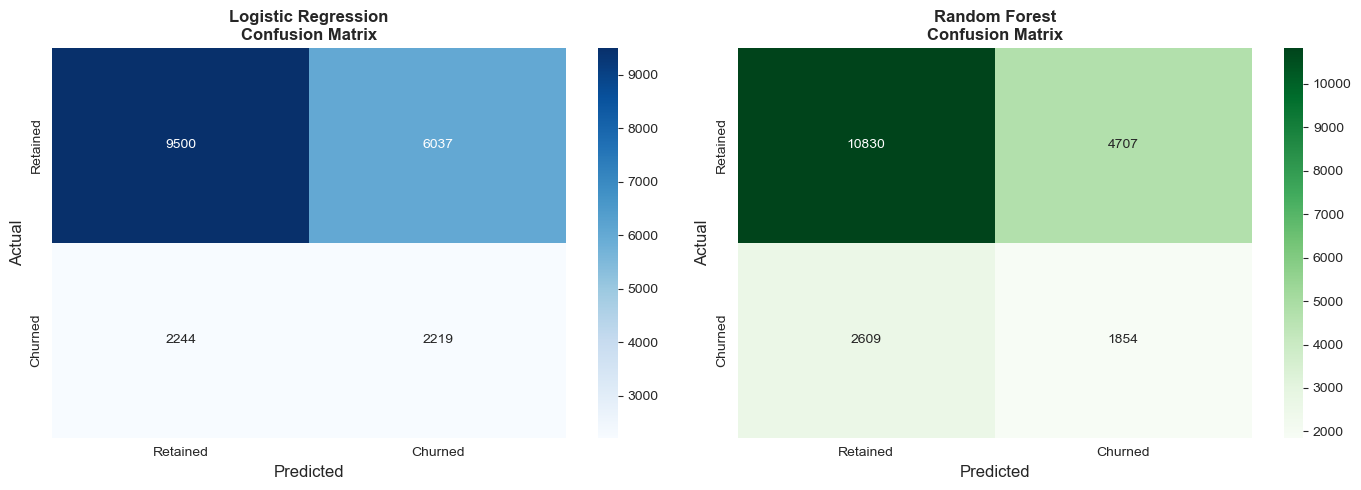

In [ ]:
# ============================================================
# SAVE PREPROCESSED DATA (Optional)
# ============================================================
# Save the preprocessed data for use in modeling notebook

print("\n💾 Saving Preprocessed Data:")
print("-" * 60)

# Convert processed arrays back to DataFrames for easier handling
# Note: This is simplified - in practice, you'd save the pipeline and transform new data

print("   ✅ Preprocessing complete!")
print("   ✅ Feature selection complete!")
print("\n   📝 Next steps:")
print("      - Use X_train_processed, y_train for model training")
print("      - Use X_test_processed, y_test for model evaluation")
print("      - Use preprocessor pipeline for new data")
print("      - Consider selected features from feature selection methods")

# ============================================================
# EXPLANATION:
# ============================================================
# In production, you would:
# 1. Save the preprocessor pipeline (using pickle or joblib)
# 2. Save the feature selector (if using one)
# 3. Apply same preprocessing to new data
# 4. Use same features for consistency
#
# Example:
#   import joblib
#   joblib.dump(preprocessor, 'preprocessor.pkl')
#   joblib.dump(selector_model, 'feature_selector.pkl')
#
# Then in production:
#   preprocessor = joblib.load('preprocessor.pkl')
#   new_data_processed = preprocessor.transform(new_data)

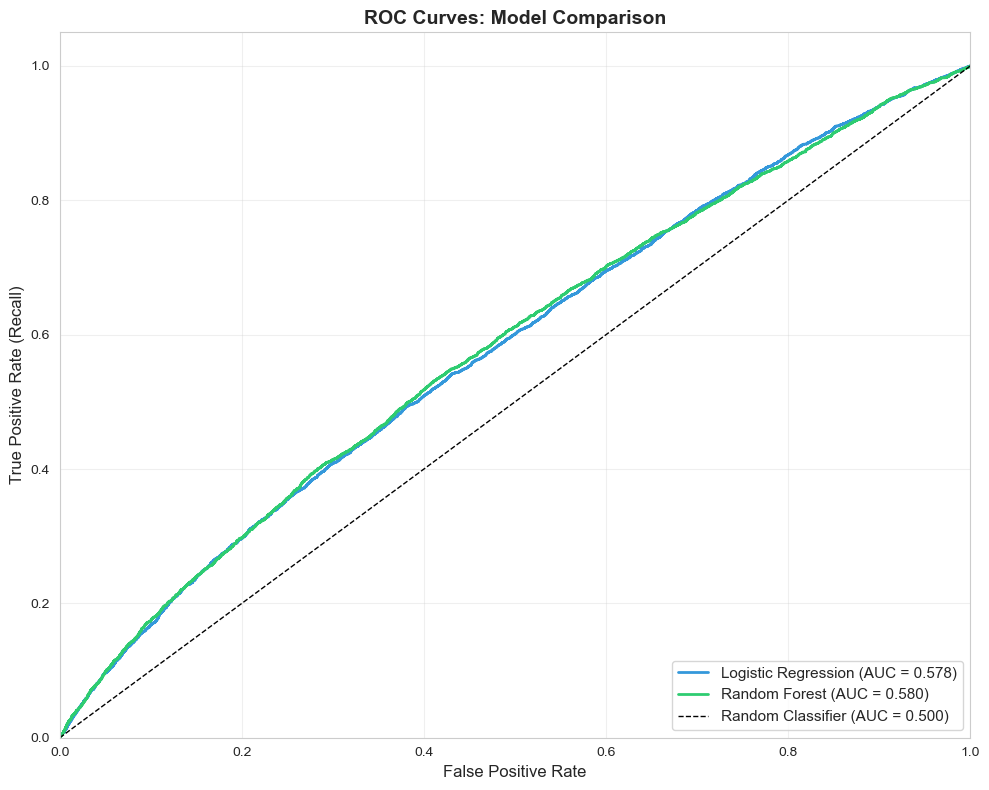


3️⃣ Model Comparison Summary:
------------------------------------------------------------


,Model,Test Accuracy,Test ROC-AUC
1,Random Forest,0.63,0.58
0,Logistic Regression,0.59,0.58



🏆 Best Model: Random Forest (ROC-AUC: 0.5804)


In [ ]:
# ============================================================
# FINAL CHECK: Data Ready for Modeling
# ============================================================

print("\n" + "=" * 60)
print("✅ FINAL CHECKLIST")
print("=" * 60)

print("\n📋 What We Have:")
print("-" * 60)
print(f"   ✅ Preprocessed training data: {X_train_processed.shape}")
print(f"   ✅ Preprocessed test data: {X_test_processed.shape}")
print(f"   ✅ Training labels: {y_train.shape}")
print(f"   ✅ Test labels: {y_test.shape}")
print(f"   ✅ Preprocessing pipeline: Ready to use")

print("\n📋 Feature Selection Results:")
print("-" * 60)
print(f"   ✅ F-test: Top {min(20, len(numeric_cols_updated))} features identified")
print(f"   ✅ L1 Regularization: {num_selected} features selected from processed data")

print("\n📋 Next Steps:")
print("-" * 60)
print("   1. Use X_train_processed and y_train to train models")
print("   2. Use X_test_processed and y_test to evaluate models")
print("   3. Apply preprocessor pipeline to new data")
print("   4. Consider using selected features for faster training")

print("\n" + "=" * 60)
print("🎉 DATA PREPARATION COMPLETE!")
print("=" * 60)

🔍 FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:
------------------------------------------------------------


,Feature,Importance
6,error_rate_7d,0.15
5,p95_latency_ms_7d,0.07
4,avg_latency_ms_7d,0.07
8,avg_output_tokens_7d,0.07
0,tenure_days,0.07
7,avg_input_tokens_7d,0.06
9,tokens_per_second_7d,0.06
2,utterances_7d,0.04
1,sessions_7d,0.03
34,subscription_status_Free,0.03


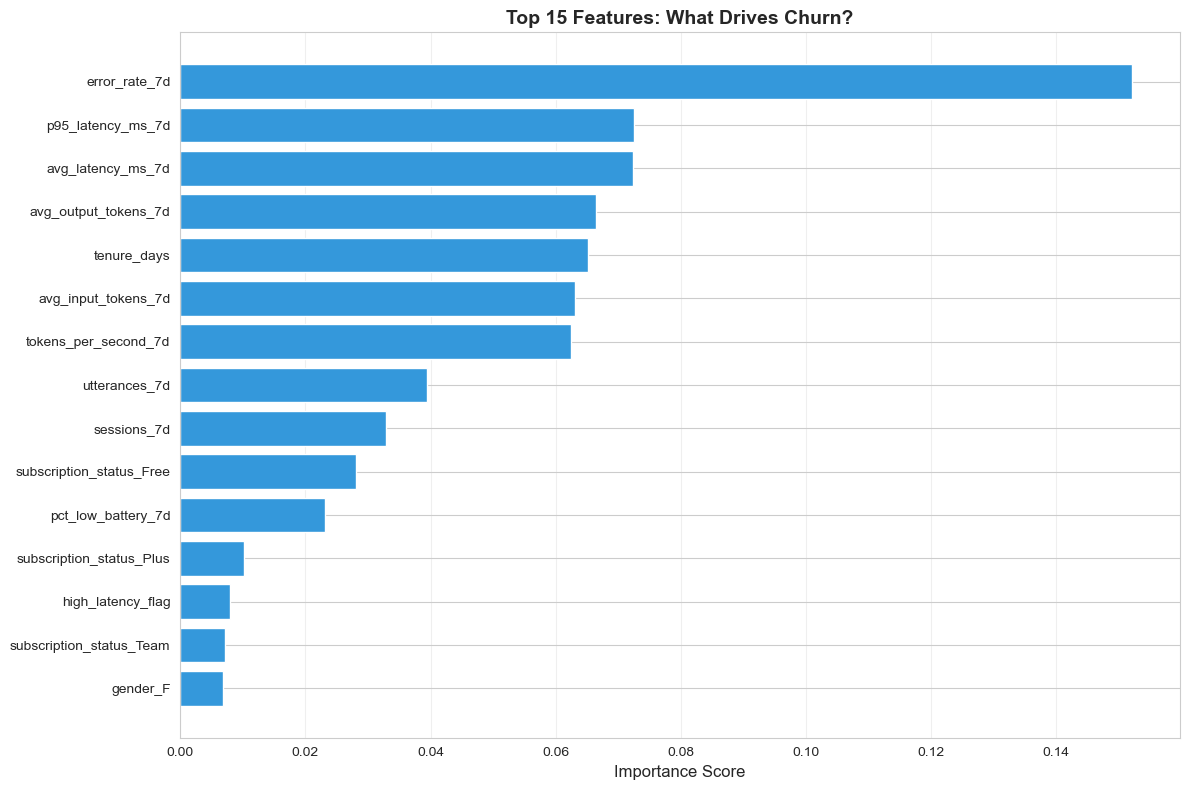

## 🎯 Summary & Next Steps

**What we accomplished:**
- ✅ **Data Loading & Inspection** - Understood our dataset structure
- ✅ **Data Validation (Milestone 2)** - Ensured data quality with 6 validation checks
- ✅ **Exploratory Data Analysis (EDA)** - Discovered patterns and relationships
- ✅ **Feature Engineering** - Created new predictive features
- ✅ **Data Preprocessing & Transformation** - Cleaned and prepared data
- ✅ **Class Imbalance Analysis** - Checked if sampling is needed (SMOTE available)
- ✅ **Scaling Technique Comparison** - Compared StandardScaler, MinMaxScaler, RobustScaler
- ✅ **PCA Analysis** - Evaluated if dimensionality reduction is beneficial
- ✅ **Feature Selection** - Identified most important features

**Key Deliverables:**
1. **Validated Dataset** - Data quality confirmed (no duplicates, missing values handled)
2. **Preprocessed Data** - Ready for modeling (X_train_processed, X_test_processed, y_train, y_test)
3. **Preprocessing Pipeline** - Reusable pipeline for new data
4. **Class Imbalance Assessment** - Determined if sampling is needed (SMOTE applied if recommended)
5. **Scaling Analysis** - Compared different scaling techniques (StandardScaler selected)
6. **PCA Components** - Optional PCA features available (X_train_pca, X_test_pca) if beneficial
7. **Feature Selection Results** - Top features identified using F-test and L1 regularization

**Next Steps (Modeling Phase):**
1. **Model Training** - Train Logistic Regression, Random Forest, XGBoost
2. **Model Evaluation** - Compare models using ROC-AUC, precision, recall
3. **Hyperparameter Tuning** - Optimize model parameters
4. **Model Selection** - Choose best model for production
5. **Model Deployment** - Deploy to production environment

**Key Takeaways:**
- Data validation is critical (60-80% of time in real projects)
- Feature engineering makes a huge difference in model performance
- Proper preprocessing prevents data leakage and improves results
- Class imbalance should be addressed (sampling or class weights)
- Scaling technique choice depends on data distribution (StandardScaler is good default)
- PCA is useful for high-dimensional data but reduces interpretability
- Feature selection reduces complexity and improves interpretability
- Pipeline-based approach ensures reproducibility and scalability

---

**🎉 Congratulations! Your data is now ready for modeling!**

**Available Data:**
- Preprocessed features: `X_train_processed`, `X_test_processed`
- Target variables: `y_train`, `y_test`
- Preprocessing pipeline: `preprocessor` (reusable for new data)
- Optional PCA features: `X_train_pca`, `X_test_pca` (if PCA was applied)
- Sampling status: Check `NEED_SAMPLING` variable (SMOTE applied if needed)

All data is ready to use in your modeling notebook!